In [39]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

image_location = Path("../../images/SomeSkyImages/")
clear_image_location = Path("../../images/SelectedSkyImages/")
enriched_df_location = Path("../../data/enriched_df.parquet")

if (not image_location.exists()) or (not enriched_df_location.exists()):
    raise FileNotFoundError

In [20]:
# Plotting Helper functions
def _weighted_fit_line(x, y, yerr):
    """
    Return a weighted linear fit and confidence band when possible.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    x = x[valid]
    y = y[valid]
    yerr = yerr[valid]

    if len(x) == 0:
        return None

    if len(x) == 1 or np.unique(x).size == 1:
        beta = np.array([0.0, y[0]], dtype=float)
        x_grid = np.linspace(x[0] - 1.0, x[0] + 1.0, 2)
        y_grid = np.full_like(x_grid, y[0], dtype=float)
        return {
            "x": x,
            "y": y,
            "yerr": yerr,
            "beta": beta,
            "x_grid": x_grid,
            "y_grid": y_grid,
            "y_lower": y_grid,
            "y_upper": y_grid,
            "m": beta[0],
            "b": beta[1],
        }

    w = 1.0 / np.square(yerr)
    X = np.column_stack([x, np.ones_like(x)])

    sqrt_w = np.sqrt(w)
    Xw = X * sqrt_w[:, None]
    yw = y * sqrt_w
    beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
    m, b = beta

    x_grid = np.linspace(x.min(), x.max(), 400)
    X_grid = np.column_stack([x_grid, np.ones_like(x_grid)])
    y_grid = X_grid @ beta

    y_fit_obs = X @ beta
    dof = max(len(x) - 2, 1)
    s2 = np.sum(w * (y - y_fit_obs) ** 2) / dof

    XtWX = X.T @ (w[:, None] * X)
    cov_beta = s2 * np.linalg.pinv(XtWX)

    y_var_grid = np.sum((X_grid @ cov_beta) * X_grid, axis=1)
    y_se_grid = np.sqrt(np.maximum(y_var_grid, 0.0))

    z = 1.96
    y_lower = y_grid - z * y_se_grid
    y_upper = y_grid + z * y_se_grid

    return {
        "x": x,
        "y": y,
        "yerr": yerr,
        "beta": beta,
        "x_grid": x_grid,
        "y_grid": y_grid,
        "y_lower": y_lower,
        "y_upper": y_upper,
        "m": m,
        "b": b,
    }

alias_labels = {
    "D": "Nightly ",
    "W": "Weekly ",
    "M": "Monthly ",
    "Q": "Quarterly ",
    "A": "Yearly ",
    "H": "Hourly ",
    "T": "",
    "min": ""
}

def plot_brightness(input_df, title_suffix=None, period="D", ax=None, plot_best_fit=True):
    df = input_df[["timestamp", "image_mean", "image_std", "exposure"]].copy()

    plot_df = df.groupby(df["timestamp"].dt.to_period(period)).agg(
        mean_image_mean=("image_mean", "mean"),
        n=("image_mean", "size"),
        pooled_image_std=("image_std", lambda s: np.sqrt(np.mean(s ** 2))),
    ).reset_index()

    plot_df["date"] = plot_df["timestamp"].dt.to_timestamp()
    plot_df["error"] = plot_df["pooled_image_std"] / np.sqrt(plot_df["n"])
    plot_df = plot_df.drop(columns=["timestamp"]).dropna(subset=["date", "mean_image_mean", "error"]).sort_values("date")

    x = mdates.date2num(np.array(plot_df["date"]))
    y = plot_df["mean_image_mean"].to_numpy(dtype=float)
    yerr = plot_df["error"].to_numpy(dtype=float)

    fit = _weighted_fit_line(x, y, yerr)
    if fit is None:
        print(f"No valid data to plot for {title_suffix or 'this dataset'}.")
        return

    dates_grid = mdates.num2date(fit["x_grid"])
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))
    else:
        fig = ax.figure

    ax.errorbar(
        plot_df["date"], y, yerr=yerr,
        fmt="o", markersize=3, capsize=3, alpha=0.5,
        label="Daily mean ± error",
    )

    if plot_best_fit:
        ax.plot(
            dates_grid, fit["y_grid"],
            color="red", linewidth=2,
            label=("Constant fit" if len(fit["x"]) == 1 else f"Weighted fit: y = {fit['m']:.4g}x + {fit['b']:.4g}"),
        )
        if len(fit["x"]) > 1:
            ax.fill_between(
                dates_grid, fit["y_lower"], fit["y_upper"],
                color="red", alpha=0.2, label="95% confidence band",
            )

    ax.set_xlabel("Date")
    ax.set_ylabel("Avg daily image brightness")
    suffix = "" if title_suffix == "" or title_suffix is None else f" ({title_suffix})"
    ax.set_title(f"{alias_labels[period]}image brightness" + suffix)
    ax.legend()
    fig.tight_layout()
    return ax


def plot_exposure(input_df, title_suffix=None, period="D", ax=None, plot_best_fit=True):
    df = input_df[["timestamp", "image_mean", "image_std", "exposure"]].copy()

    exposure_daily = df.groupby(df["timestamp"].dt.to_period(period)).agg(
        mean_exposure=("exposure", "mean"),
        n=("exposure", "size"),
        exposure_std=("exposure", "std"),
    ).reset_index()

    exposure_daily["date"] = exposure_daily["timestamp"].dt.to_timestamp()
    exposure_daily["error"] = exposure_daily["exposure_std"] / np.sqrt(exposure_daily["n"])
    exposure_daily = exposure_daily.drop(columns=["timestamp"]).dropna(subset=["date", "mean_exposure"]).sort_values("date")

    plot_df = exposure_daily.dropna(subset=["error"])
    x = mdates.date2num(np.array(plot_df["date"]))
    y = plot_df["mean_exposure"].to_numpy(dtype=float)
    yerr = plot_df["error"].to_numpy(dtype=float)

    fit = _weighted_fit_line(x, y, yerr)
    if fit is None:
        print(f"No valid data to plot for {title_suffix or 'this dataset'}.")
        return

    dates_grid = mdates.num2date(fit["x_grid"])
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))
    else:
        fig = ax.figure

    ax.errorbar(
        plot_df["date"], y, yerr=yerr,
        fmt="o", markersize=3, capsize=3, alpha=0.6,
        label="Nightly mean exposure ± error",
    )

    if plot_best_fit:
        ax.plot(
            dates_grid, fit["y_grid"],
            color="red", linewidth=2,
            label=("Constant fit" if len(fit["x"]) == 1 else f"Weighted fit: y = {fit['m']:.4g}x + {fit['b']:.4g}"),
        )

        if len(fit["x"]) > 1:
            ax.fill_between(
                dates_grid, fit["y_lower"], fit["y_upper"],
                color="red", alpha=0.2, label="95% confidence band",
            )

    ax.set_xlabel("Date")
    ax.set_ylabel("Mean nightly exposure time")
    suffix = "" if title_suffix == "" or title_suffix is None else f" ({title_suffix})"
    ax.set_title(f"{alias_labels[period]}mean exposure time" + suffix)
    ax.legend()
    fig.tight_layout()
    return ax


def plot_luminous_flux(input_df, title_suffix=None, period="D", ax=None, plot_best_fit=True):
    df = input_df[["timestamp", "image_mean", "image_std", "exposure"]].copy()
    df = df.assign(luminous_flux=df["image_mean"] / df["exposure"])
    df = df.dropna(subset=["timestamp", "image_mean", "image_std", "exposure", "luminous_flux"])

    sigma_exposure = 0.0
    df["luminous_flux_error"] = np.sqrt(
        (df["image_std"] / df["exposure"])**2 +
        ((df["image_mean"] * sigma_exposure) / (df["exposure"]**2))**2
    )

    daily = df.groupby(df["timestamp"].dt.to_period(period)).agg(
        mean_luminous_flux=("luminous_flux", "mean"),
        n=("luminous_flux", "size"),
        flux_error_rss=("luminous_flux_error", lambda s: np.sqrt(np.sum(np.square(s))) / len(s)),
    ).reset_index()

    daily["date"] = daily["timestamp"].dt.to_timestamp()
    daily["error"] = daily["flux_error_rss"]
    daily = daily.drop(columns=["timestamp"]).dropna(subset=["date", "mean_luminous_flux"]).sort_values("date")

    plot_df = daily.dropna(subset=["error"])
    x = mdates.date2num(np.array(plot_df["date"]))
    y = plot_df["mean_luminous_flux"].to_numpy(dtype=float)
    yerr = plot_df["error"].to_numpy(dtype=float)

    fit = _weighted_fit_line(x, y, yerr)
    if fit is None:
        print(f"No valid data to plot for {title_suffix or 'this dataset'}.")
        return

    dates_grid = mdates.num2date(fit["x_grid"])
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))
    else:
        fig = ax.figure

    ax.errorbar(
            plot_df["date"], y, yerr=yerr,
            fmt="o", markersize=3, capsize=3, alpha=0.6,
            label="Nightly mean luminous flux ± error",
    )

    if plot_best_fit:
        ax.plot(
            dates_grid, fit["y_grid"],
            color="red", linewidth=2,
            label=("Constant fit" if len(fit["x"]) == 1 else f"Weighted fit: y = {fit['m']:.4g}x + {fit['b']:.4g}"),
        )

        if len(fit["x"]) > 1:
            ax.fill_between(
                dates_grid, fit["y_lower"], fit["y_upper"],
                color="red", alpha=0.2, label="95% confidence band",
            )

    ax.set_xlabel("Date")
    ax.set_ylabel("Mean luminous flux")
    suffix = "" if title_suffix == "" or title_suffix is None else f" ({title_suffix})"
    ax.set_title(f"{alias_labels[period]}luminous flux" + suffix)
    ax.legend()
    fig.tight_layout()
    return ax

In [57]:
enriched_df = pd.read_parquet(enriched_df_location)

,date,time,exposure,filename,source_file,timestamp,image_paths,image_mean,image_sum,image_min,image_max,image_std,image_medians
8,2010/08/11,22:38:00,2.7883,000021274,2010-08.parquet,2010-08-11 22:38:00,../../images/SomeSkyImages/2010-08/AllSkyImage...,157.789822,19822662,105,242,29.416727,156.0
9,2010/08/11,22:39:17,2.4769,000021275,2010-08.parquet,2010-08-11 22:39:17,../../images/SomeSkyImages/2010-08/AllSkyImage...,159.858382,20082529,102,242,25.961395,158.0
10,2010/08/11,22:40:17,2.4769,000021276,2010-08.parquet,2010-08-11 22:40:17,../../images/SomeSkyImages/2010-08/AllSkyImage...,163.385713,20525657,115,240,25.684782,161.0
11,2010/08/11,22:41:34,2.4769,000021277,2010-08.parquet,2010-08-11 22:41:34,../../images/SomeSkyImages/2010-08/AllSkyImage...,166.985608,20977901,117,245,28.818942,163.0
12,2010/08/11,22:42:34,2.4769,000021278,2010-08.parquet,2010-08-11 22:42:34,../../images/SomeSkyImages/2010-08/AllSkyImage...,158.146314,19867447,99,248,34.864647,154.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,2026/03/25,05:40:08,32.0241,000422467,2026-03.parquet,2026-03-25 05:40:08,../../images/SomeSkyImages/2026-03/AllSkyImage...,103.790141,13038844,51,221,19.991641,102.0
5,2026/03/25,05:40:41,32.0241,000422468,2026-03.parquet,2026-03-25 05:40:41,../../images/SomeSkyImages/2026-03/AllSkyImage...,103.978412,13062496,57,235,19.158357,102.0
6,2026/03/25,05:41:34,36.3559,000422469,2026-03.parquet,2026-03-25 05:41:34,../../images/SomeSkyImages/2026-03/AllSkyImage...,107.699698,13529990,56,232,20.021279,105.0
7,2026/03/25,05:42:11,36.3559,000422470,2026-03.parquet,2026-03-25 05:42:11,../../images/SomeSkyImages/2026-03/AllSkyImage...,107.371680,13488782,59,253,21.015155,105.0


<Axes: title={'center': 'Nightly luminous flux (Full Dataset)'}, xlabel='Date', ylabel='Mean luminous flux'>

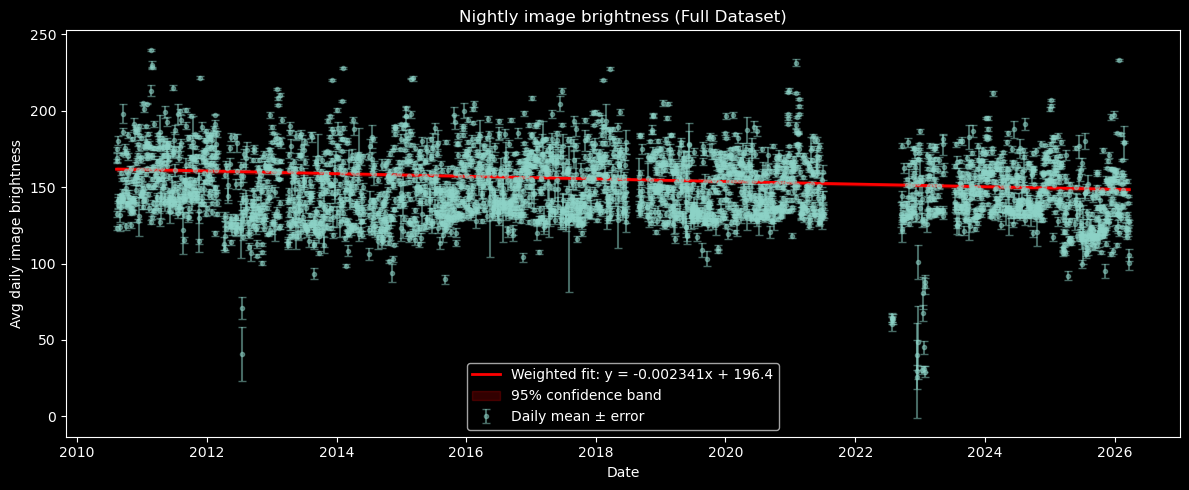

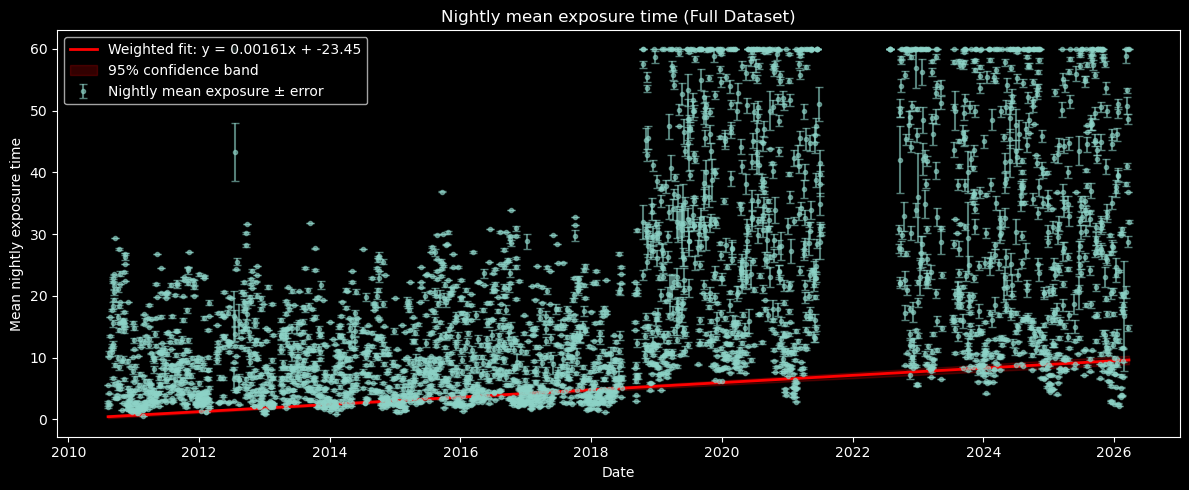

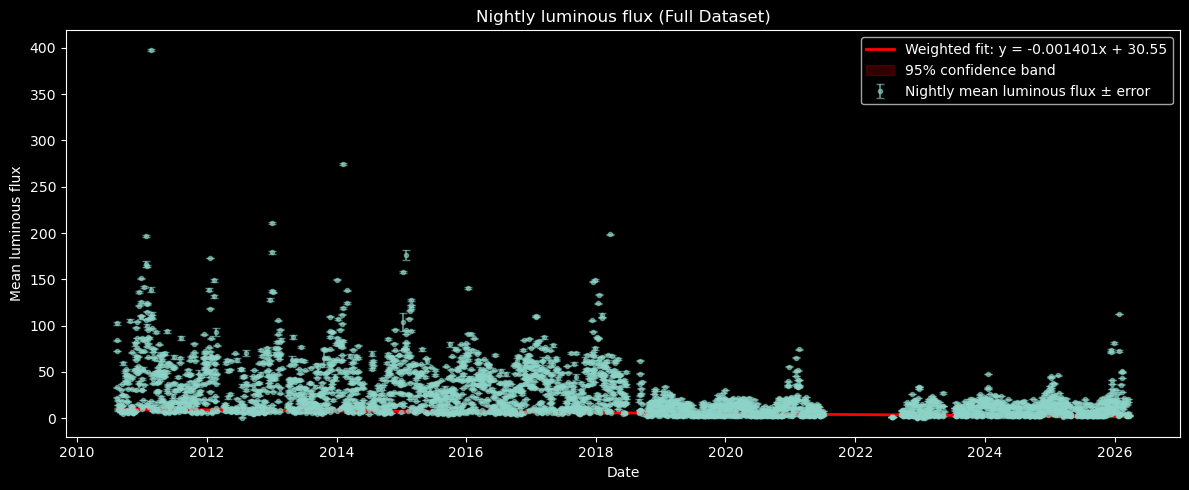

In [22]:
_ = plot_brightness(enriched_df, "Full Dataset")
_ = plot_exposure(enriched_df, "Full Dataset")
_ = plot_luminous_flux(enriched_df, "Full Dataset")

In [23]:
recent_df = enriched_df[
        (pd.to_datetime(enriched_df["date"], format="%Y/%m/%d", errors="coerce").dt.year >= 2022)
]

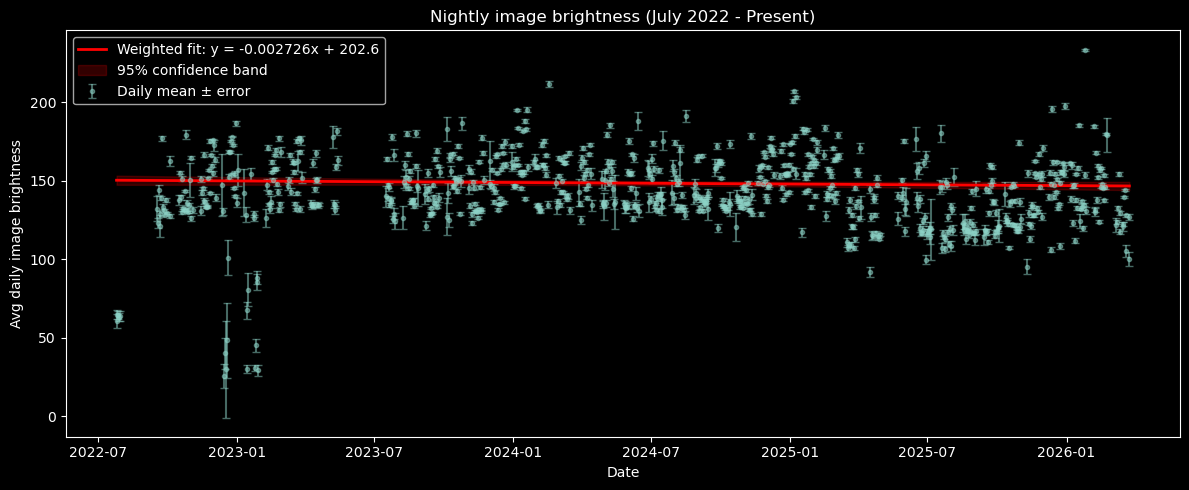

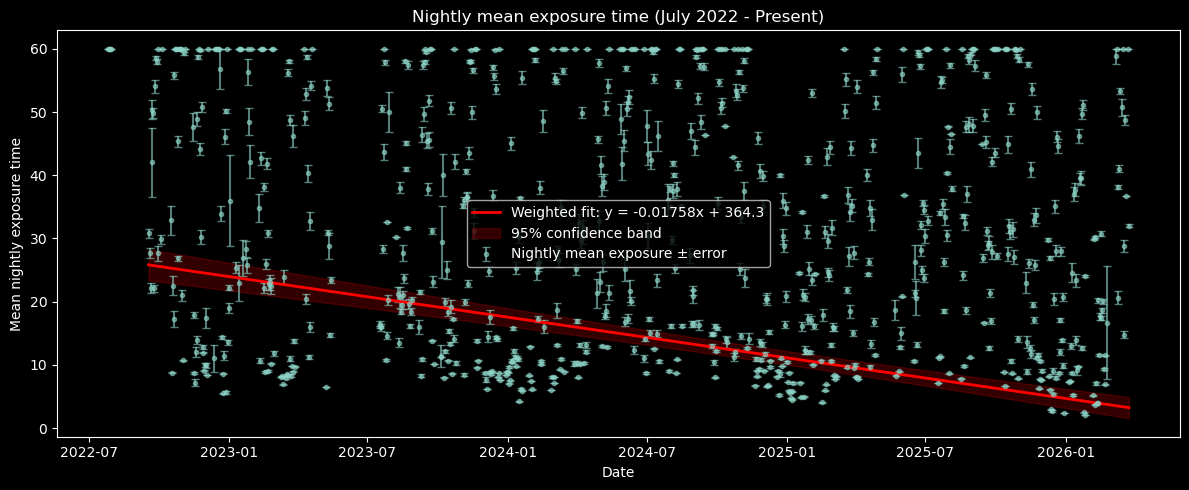

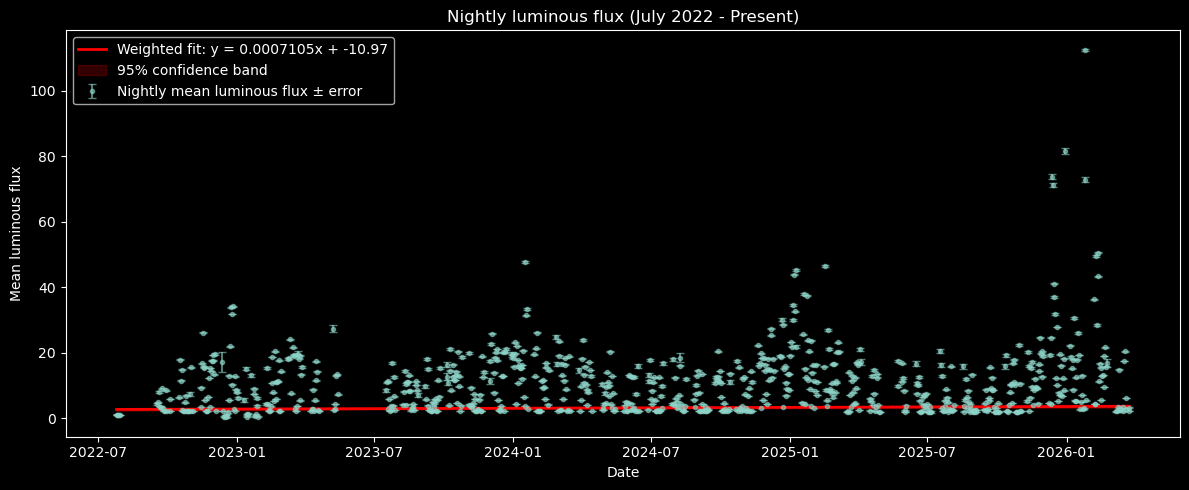

In [24]:
_ = plot_brightness(recent_df, "July 2022 - Present")
_ = plot_exposure(recent_df, "July 2022 - Present")
_ = plot_luminous_flux(recent_df, "July 2022 - Present")

In [25]:
enriched_df

,date,time,exposure,filename,source_file,timestamp,image_paths,image_mean,image_sum,image_min,image_max,image_std,image_medians
8,2010/08/11,22:38:00,2.7883,000021274,2010-08.parquet,2010-08-11 22:38:00,../../images/SomeSkyImages2010-08/AllSkyImage0...,157.789822,19822662,105,242,29.416727,156.0
9,2010/08/11,22:39:17,2.4769,000021275,2010-08.parquet,2010-08-11 22:39:17,../../images/SomeSkyImages2010-08/AllSkyImage0...,159.858382,20082529,102,242,25.961395,158.0
10,2010/08/11,22:40:17,2.4769,000021276,2010-08.parquet,2010-08-11 22:40:17,../../images/SomeSkyImages2010-08/AllSkyImage0...,163.385713,20525657,115,240,25.684782,161.0
11,2010/08/11,22:41:34,2.4769,000021277,2010-08.parquet,2010-08-11 22:41:34,../../images/SomeSkyImages2010-08/AllSkyImage0...,166.985608,20977901,117,245,28.818942,163.0
12,2010/08/11,22:42:34,2.4769,000021278,2010-08.parquet,2010-08-11 22:42:34,../../images/SomeSkyImages2010-08/AllSkyImage0...,158.146314,19867447,99,248,34.864647,154.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,2026/03/25,05:40:08,32.0241,000422467,2026-03.parquet,2026-03-25 05:40:08,../../images/SomeSkyImages2026-03/AllSkyImage0...,103.790141,13038844,51,221,19.991641,102.0
5,2026/03/25,05:40:41,32.0241,000422468,2026-03.parquet,2026-03-25 05:40:41,../../images/SomeSkyImages2026-03/AllSkyImage0...,103.978412,13062496,57,235,19.158357,102.0
6,2026/03/25,05:41:34,36.3559,000422469,2026-03.parquet,2026-03-25 05:41:34,../../images/SomeSkyImages2026-03/AllSkyImage0...,107.699698,13529990,56,232,20.021279,105.0
7,2026/03/25,05:42:11,36.3559,000422470,2026-03.parquet,2026-03-25 05:42:11,../../images/SomeSkyImages2026-03/AllSkyImage0...,107.371680,13488782,59,253,21.015155,105.0


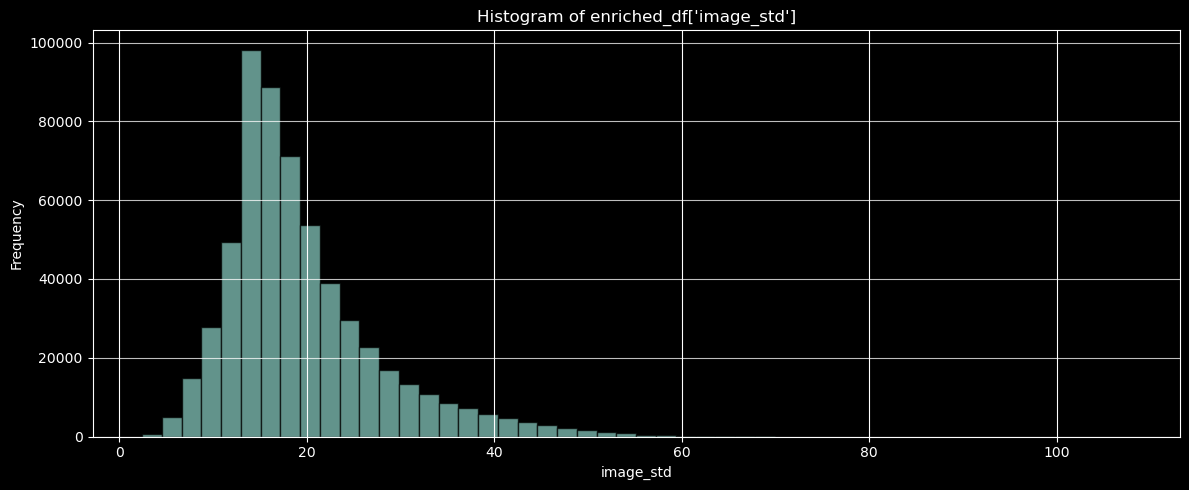

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))
enriched_df['image_std'].hist(ax=ax, bins=50, edgecolor='black', alpha=0.7)
plt.title('Histogram of enriched_df[\'image_std\']')
plt.xlabel('image_std')
plt.ylabel('Frequency')
ax.grid(axis='y', alpha=0.75)
fig.tight_layout()

In [27]:
date_dt = pd.to_datetime(enriched_df["date"], format="%Y/%m/%d", errors="coerce")

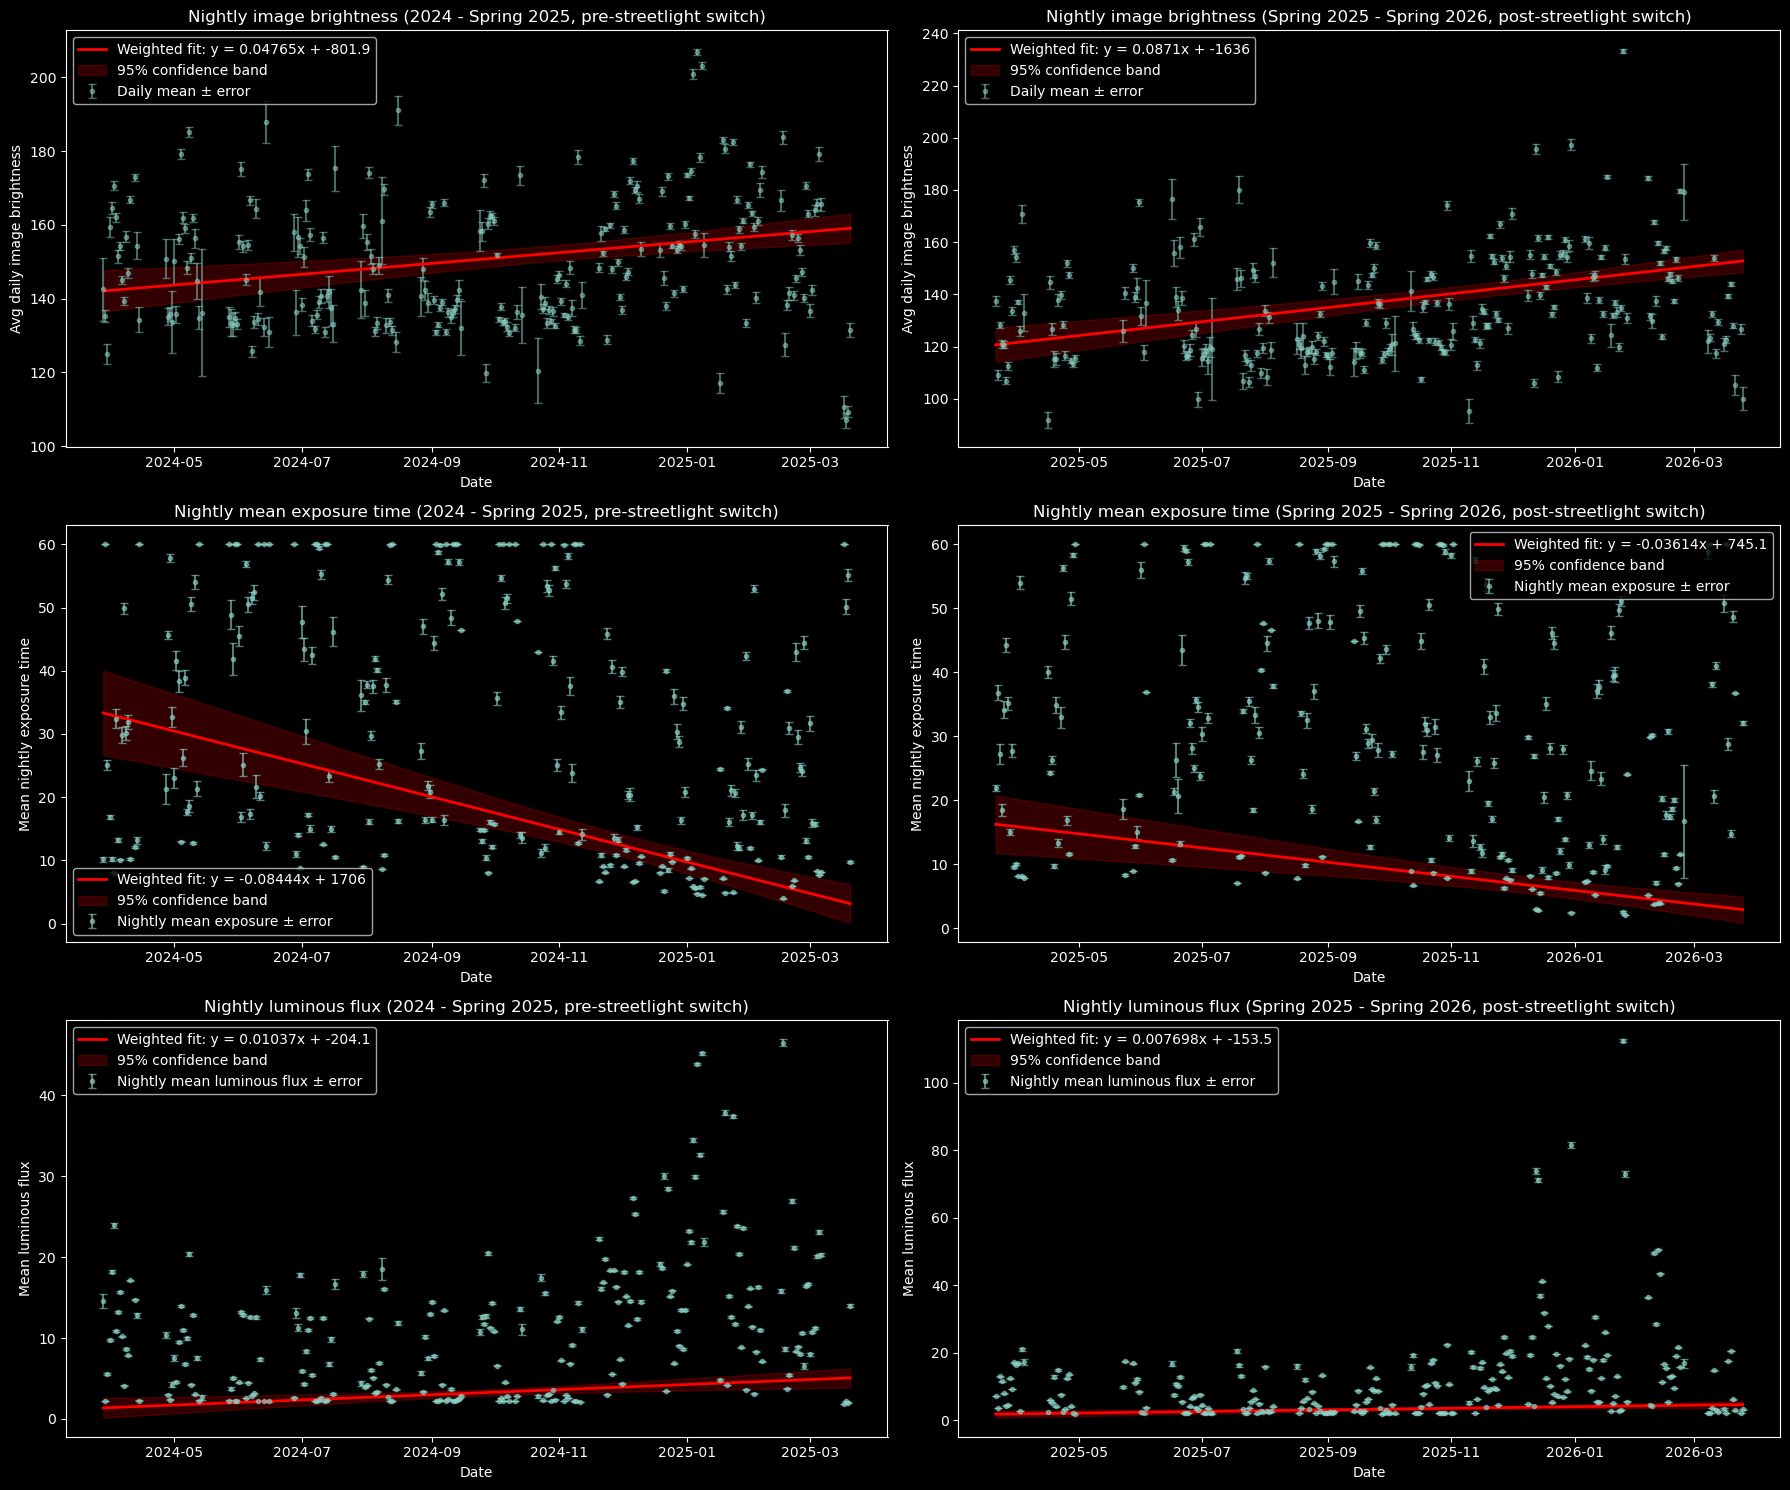

In [28]:
def plot_graph(split_date = "2025-03-21", period="D"):
    global preswitch_df, postswitch_df
    fig, axes = plt.subplots(3, 2, figsize=(18, 15), sharex=False)

    preswitch_df = enriched_df[
        (date_dt >= pd.to_datetime(split_date).replace(2024)) &
        (date_dt < pd.to_datetime(split_date))
    ]
    postswitch_df = enriched_df[
        # (date_dt.dt.year >= 2025)
        (date_dt >= pd.to_datetime(split_date))
    ]

    plot_brightness(preswitch_df, "2024 - Spring 2025, pre-streetlight switch", period, ax=axes[0, 0])
    plot_exposure(preswitch_df, "2024 - Spring 2025, pre-streetlight switch", period, ax=axes[1, 0])
    plot_luminous_flux(preswitch_df, "2024 - Spring 2025, pre-streetlight switch", period, ax=axes[2, 0])
    plot_brightness(postswitch_df, "Spring 2025 - Spring 2026, post-streetlight switch", period, ax=axes[0, 1])
    plot_exposure(postswitch_df, "Spring 2025 - Spring 2026, post-streetlight switch", period, ax=axes[1, 1])
    _ = plot_luminous_flux(postswitch_df, "Spring 2025 - Spring 2026, post-streetlight switch", period, ax=axes[2, 1])
    plt.tight_layout()

plot_graph(period="D")

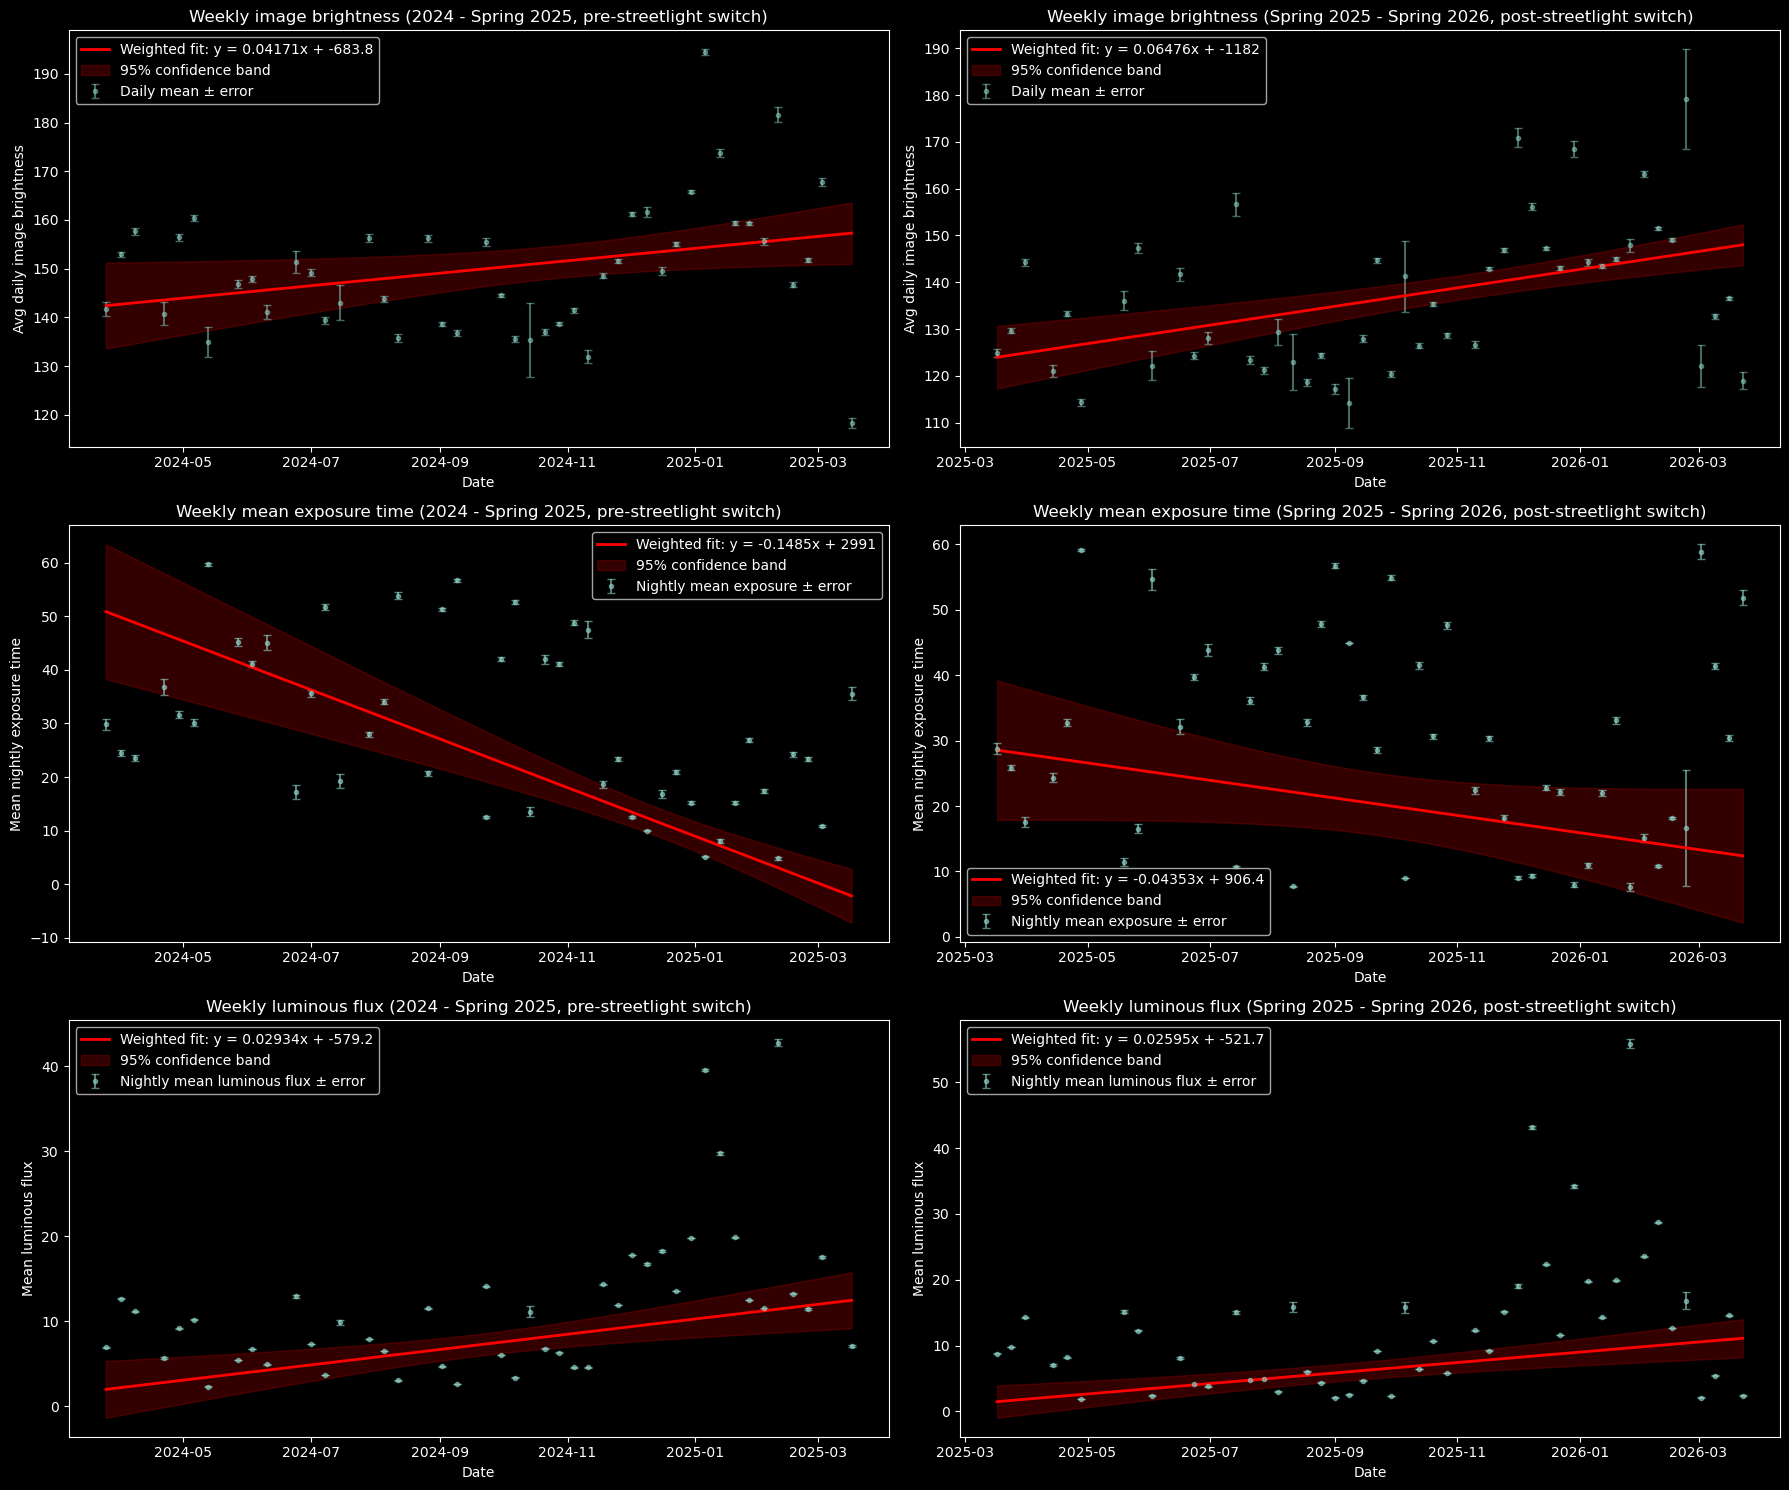

In [29]:
plot_graph(period="W")

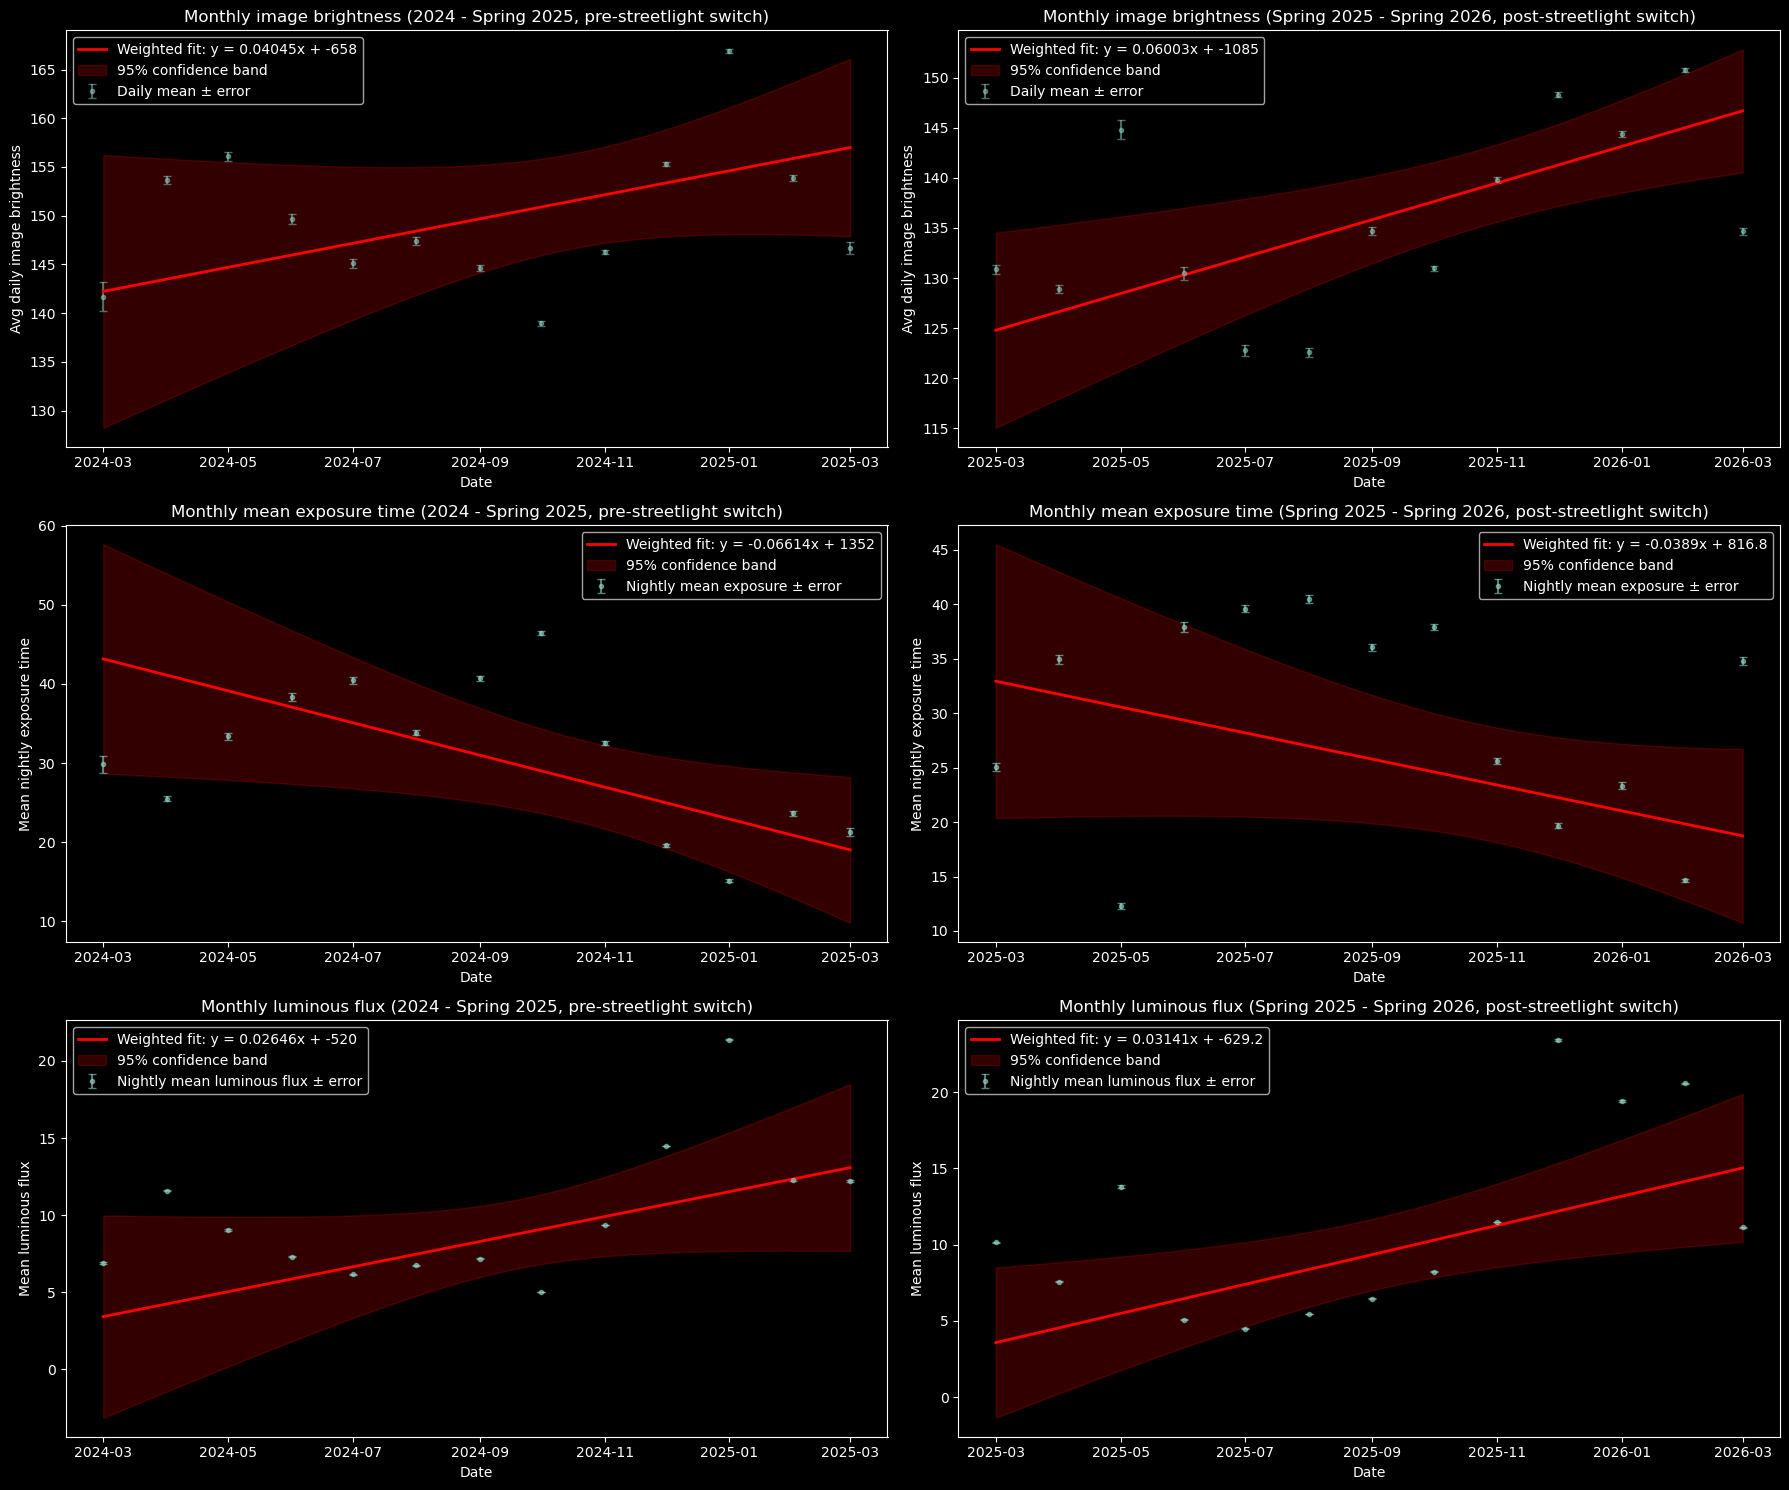

In [30]:
plot_graph(period="M")

In [31]:
len(preswitch_df), len(postswitch_df), len(preswitch_df) + len(postswitch_df)

(53626, 59151, 112777)

---

In [70]:
record_set = set([
    str(clear_image_location.joinpath(f"{source_file[:-8]}/AllSkyImage{filename}.JPG"))
    for filename, source_file in enriched_df[["filename", 'source_file']].to_numpy()
])
image_set = set(list([str(x) for x in clear_image_location.glob("20*-*/*.JPG")]))

In [71]:
record_set.pop(), image_set.pop()

('../../images/SelectedSkyImages/2013-10/AllSkyImage000544800.JPG',
 '../../images/SelectedSkyImages/2024-04/AllSkyImage002185670.JPG')

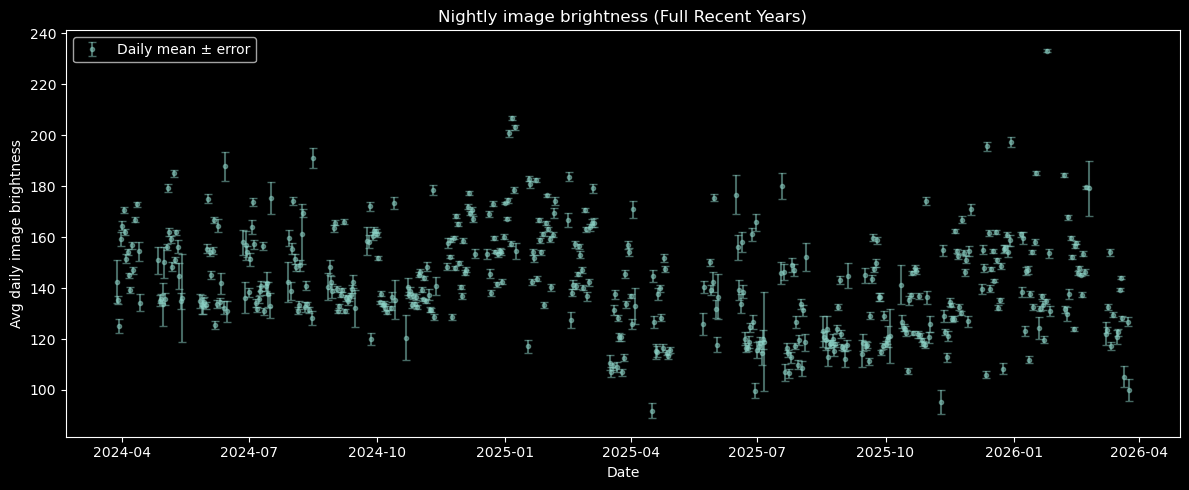

In [72]:
recent_years_df = enriched_df[
    (date_dt >= pd.to_datetime("2024-03-21"))
]
_ = plot_brightness(recent_years_df, "Full Recent Years", plot_best_fit=False)

In [73]:
recent_years_df["image_paths"].str.replace(
    str(image_location), str(clear_image_location)
)

condition = recent_years_df["image_paths"].str.replace(
    str(image_location), str(clear_image_location)
).isin(image_set)


(112777, 24910)

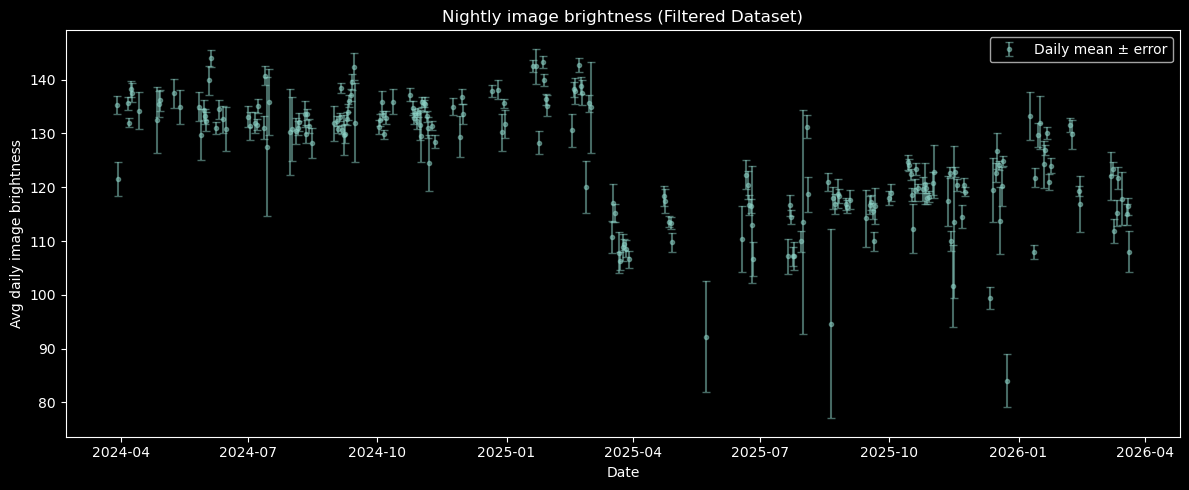

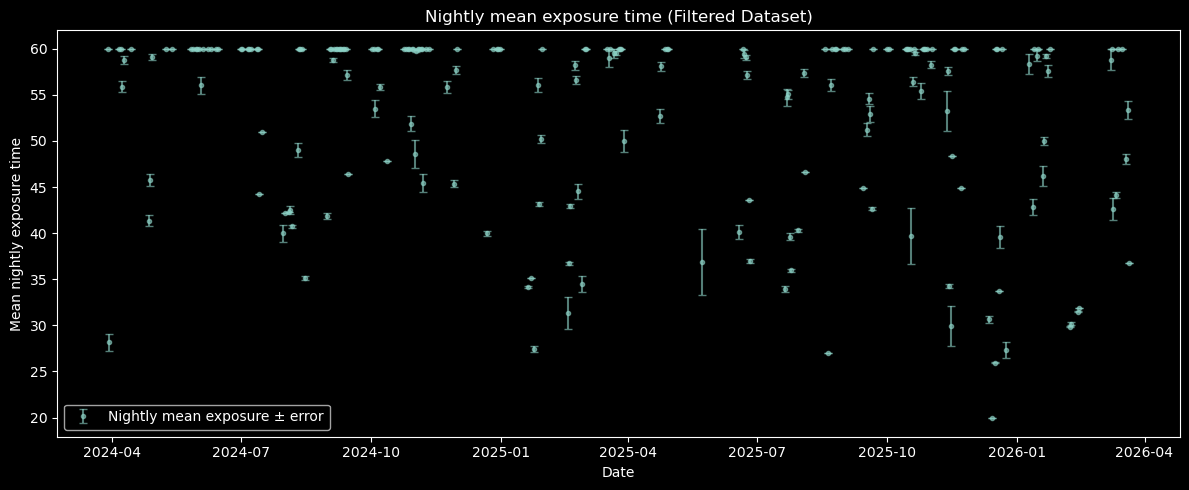

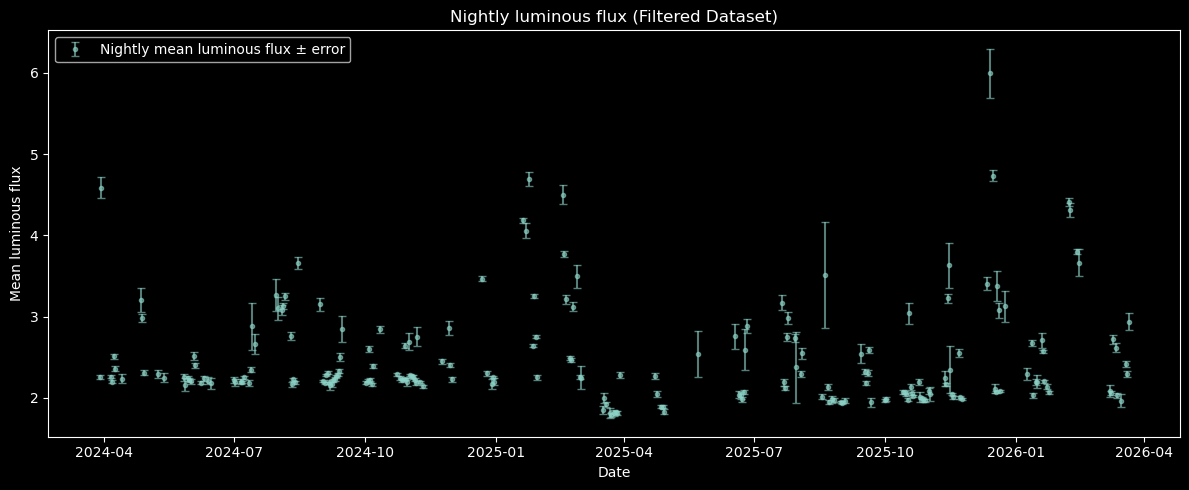

In [74]:
only_clear_nights_df = recent_years_df[condition]
# only_clear_nights_df = only_clear_nights_df[only_clear_nights_df["exposure"] > 50]

plot_line_of_fit = False

_ = plot_brightness(only_clear_nights_df, "Filtered Dataset", plot_best_fit=plot_line_of_fit)
_ = plot_exposure(only_clear_nights_df, "Filtered Dataset", plot_best_fit=plot_line_of_fit)
_ = plot_luminous_flux(only_clear_nights_df, "Filtered Dataset", plot_best_fit=plot_line_of_fit)
len(recent_years_df), len(recent_years_df[condition])

In [75]:
before_camera_wonk = only_clear_nights_df[
    (only_clear_nights_df["date"] >= "2025/01/01") &
    (only_clear_nights_df["date"] < "2025/03/04")
]

after_camera_back = only_clear_nights_df[
    (only_clear_nights_df["date"] >= "2025/06/21") &
    (only_clear_nights_df["date"] < "2025/08/20")
]

(
    len(before_camera_wonk), len(after_camera_back),
    before_camera_wonk["image_mean"].mean(),
    before_camera_wonk["image_mean"].std(),
    after_camera_back["image_mean"].mean(),
    after_camera_back["image_mean"].std()
)

(1350,
 1549,
 np.float64(138.63556451211096),
 np.float64(5.361199908805324),
 np.float64(115.06698532889817),
 np.float64(6.711407269585075))

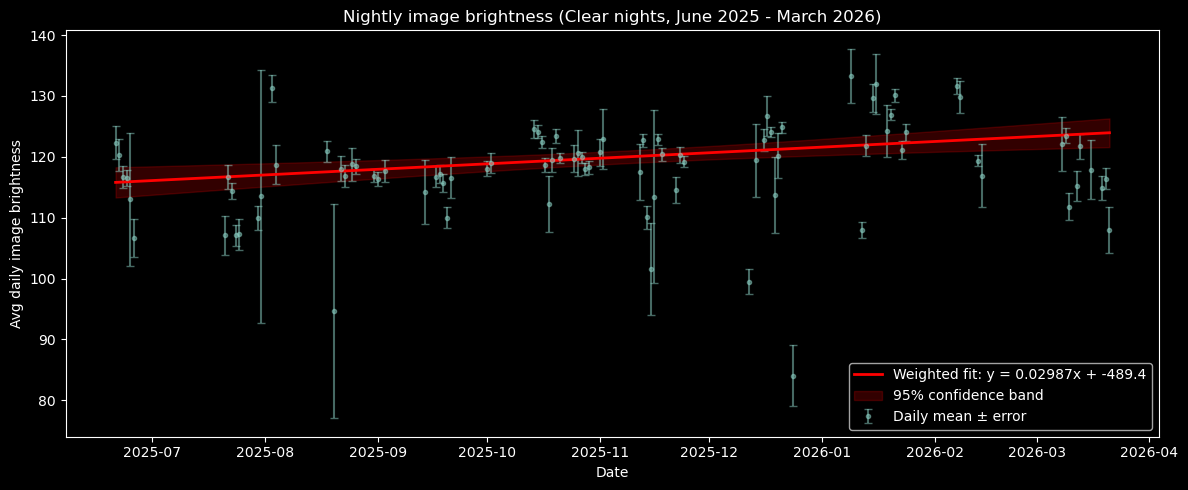

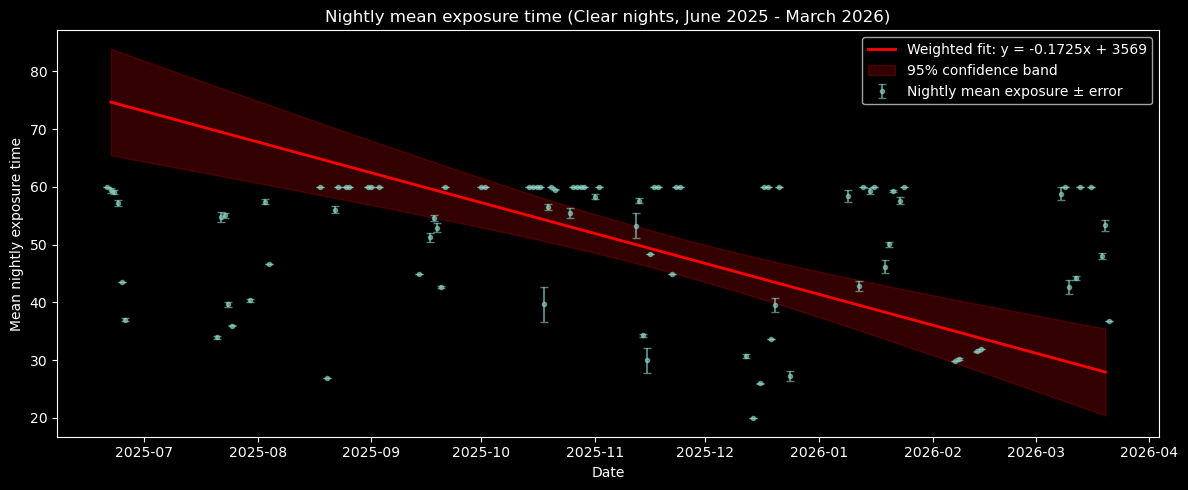

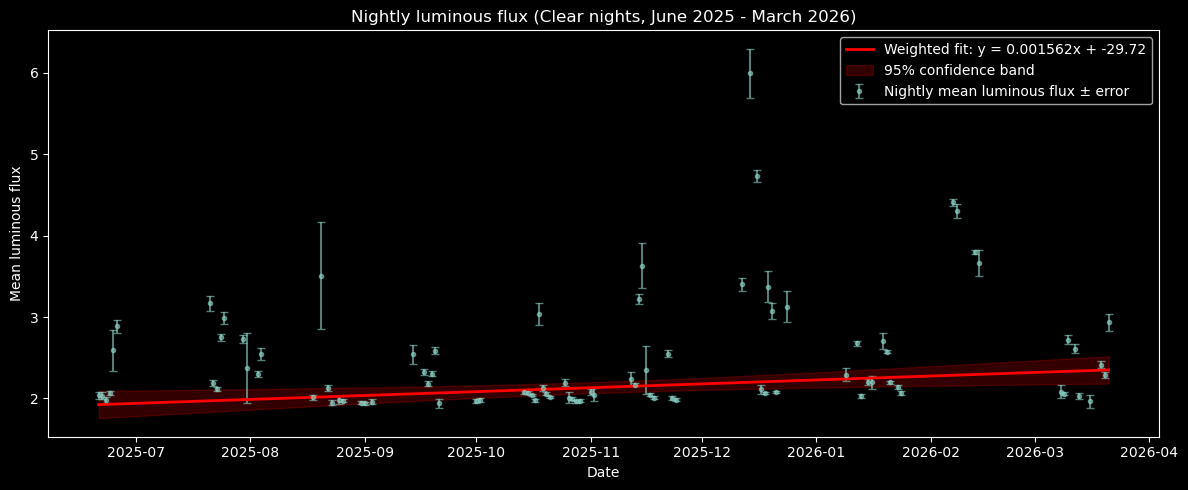

In [76]:
all_after_camera_back = only_clear_nights_df[
    (only_clear_nights_df["date"] >= "2025/06/21")
]

plot_line_of_fit = True

_ = plot_brightness(all_after_camera_back, "Clear nights, June 2025 - March 2026", plot_best_fit=plot_line_of_fit, period="D")
_ = plot_exposure(all_after_camera_back, "Clear nights, June 2025 - March 2026", plot_best_fit=plot_line_of_fit, period="D")
_ = plot_luminous_flux(all_after_camera_back, "Clear nights, June 2025 - March 2026", plot_best_fit=plot_line_of_fit, period="D")

In [77]:
def line_values_and_percent_change(m, b, x_start, x_end):
    start_y = m * x_start + b
    end_y = m * x_end + b
    percent_change = ((end_y - start_y) / start_y) * 100
    return start_y, end_y, percent_change

x_start = mdates.date2num(pd.to_datetime("2025-06-21"))
x_end = mdates.date2num(pd.to_datetime("2026-03-28"))

brightness_m = 0.02987
brightness_b = -489.4

lumflux_m = 0.001562
lumflux_b = -29.72

(
    line_values_and_percent_change(brightness_m, brightness_b, x_start, x_end),
    line_values_and_percent_change(lumflux_m, lumflux_b, x_start, x_end),
)

((np.float64(115.76620000000003),
  np.float64(124.12980000000005),
  np.float64(7.224561227715877)),
 (np.float64(1.926120000000001),
  np.float64(2.3634800000000027),
  np.float64(22.70678877743866)))